# 📊 Exploratory Data Analysis — Telco Customer Churn

This notebook explores the Telco Customer Churn dataset to understand patterns and features
that drive customer attrition. Insights from this EDA directly inform feature engineering
and model design in the training notebook.

## 1. Setup & Data Loading

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# Resolve project root (one level up from notebooks/)
PROJECT_ROOT = Path(os.path.abspath('')).parent

print(f'Project root: {PROJECT_ROOT}')

print('Libraries loaded successfully.')

Project root: e:\Workspace and ideas\churn-prediction-pipeline
Libraries loaded successfully.


In [16]:
# Load dataset
df = pd.read_csv(PROJECT_ROOT / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Basic cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Dataset shape: {df.shape}')
print(f'Churn rate: {df["Churn"].mean():.2%}')
df.head()

Dataset shape: (7043, 21)
Churn rate: 26.54%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Dataset Overview

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [19]:
# Check missing values
missing = df.isnull().sum()
missing[missing > 0]

TotalCharges    11
dtype: int64

In [20]:
# Check class distribution
print('Churn value counts:')
print(df['Churn'].value_counts())
print(f'\nImbalance ratio: {df["Churn"].value_counts()[0] / df["Churn"].value_counts()[1]:.2f}:1')

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Imbalance ratio: 2.77:1


## 3. Target Variable — Churn Distribution

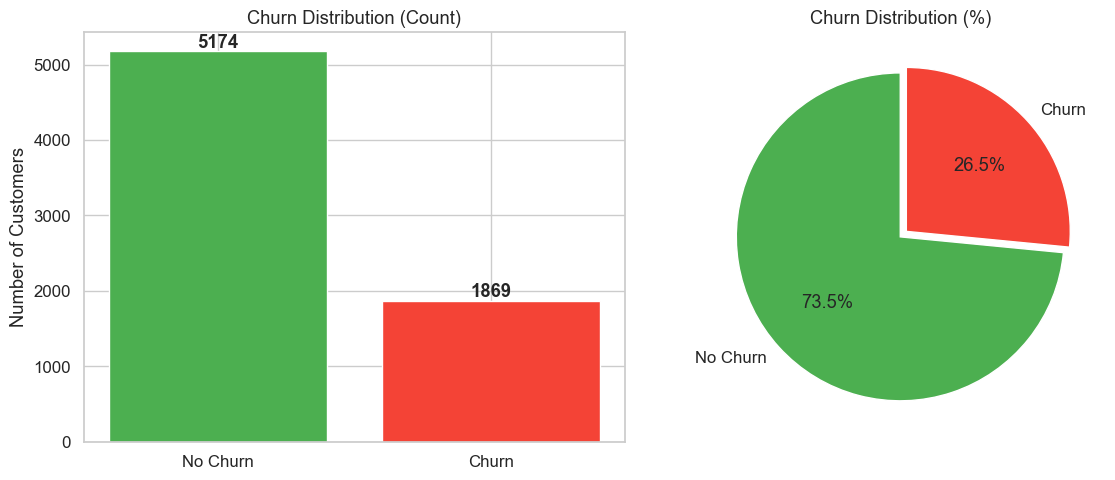

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentage pie
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Distribution (%)')

plt.tight_layout()
plt.show()

**Insight:** The dataset is imbalanced — roughly 26.5% churn vs 73.5% retained.
This will require careful handling during modeling (class weights or resampling).

## 4. Numeric Feature Distributions

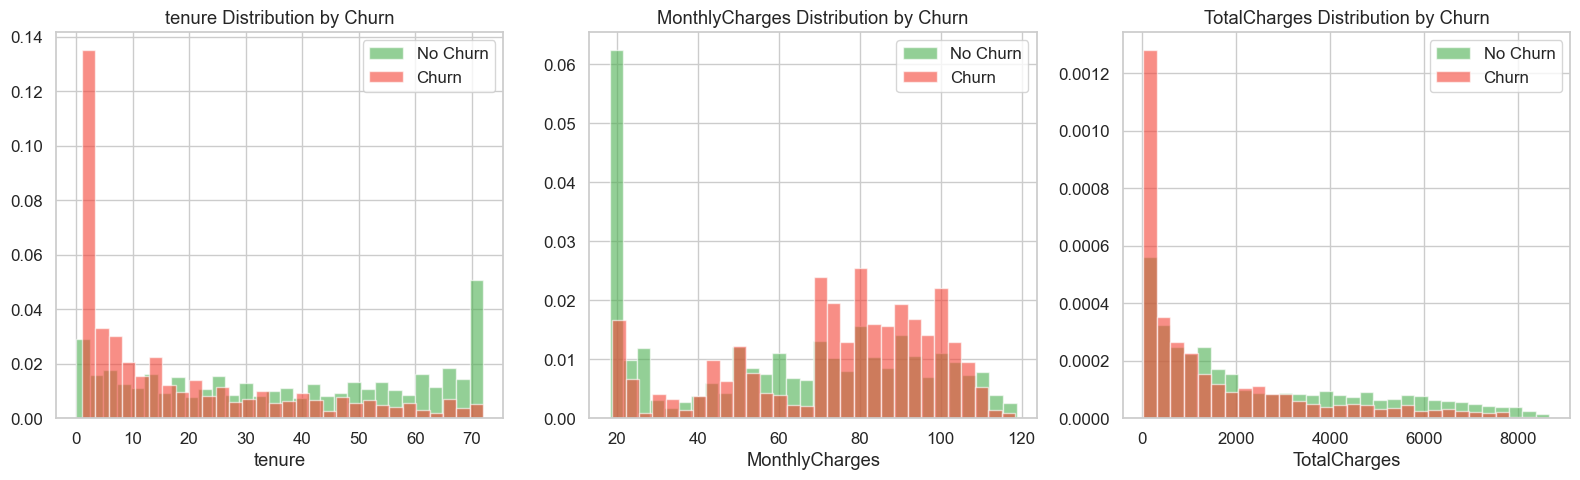

In [22]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    for churn_val, color, label in [(0, '#4CAF50', 'No Churn'), (1, '#F44336', 'Churn')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(f'{col} Distribution by Churn')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

**Key observations:**
- **Tenure:** Churned customers are heavily concentrated in the first 0–12 months. Long-tenure customers rarely churn.
- **MonthlyCharges:** Churners tend to have higher monthly charges (60–100 range).
- **TotalCharges:** Churners skew towards lower total charges (short tenure → less accumulated spend).

## 5. Churn Rates by Categorical Features

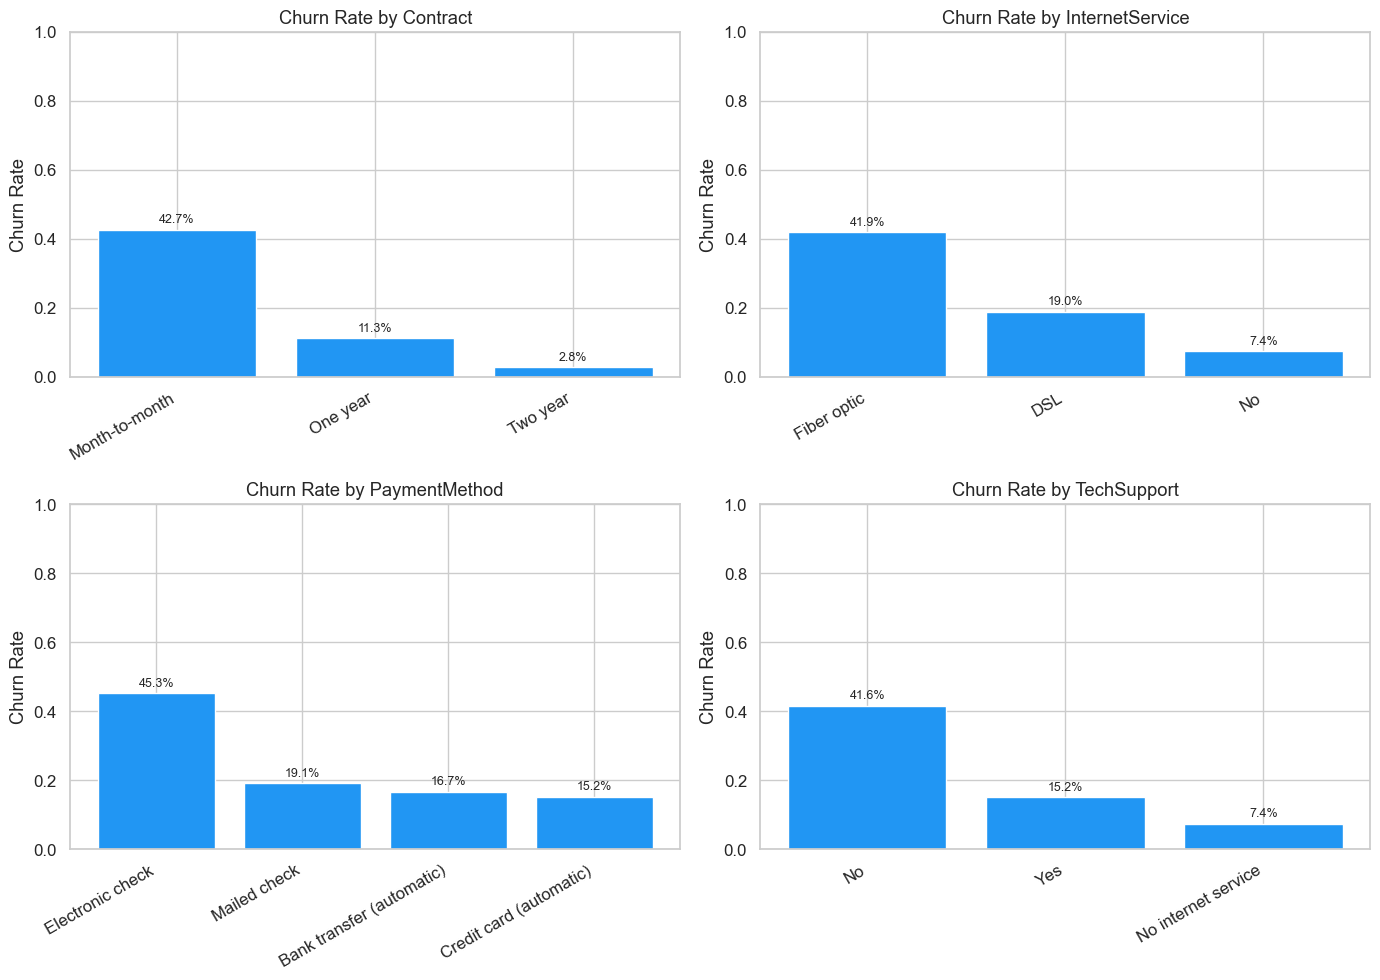

In [23]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(cat_features):
    ax = axes[idx // 2][idx % 2]
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(churn_rate)), churn_rate.values, color='#2196F3')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=30, ha='right')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Key findings:**
- **Contract:** Month-to-month customers churn at ~42%, vs ~3% for two-year contracts. This is the strongest predictor.
- **Internet Service:** Fiber optic customers churn at ~42%, much higher than DSL (~19%). Possible quality/pricing issue.
- **Payment Method:** Electronic check users churn at ~45% — significantly higher than other methods.
- **Tech Support:** Customers without tech support churn ~2x more than those with it.

## 6. Correlation Analysis

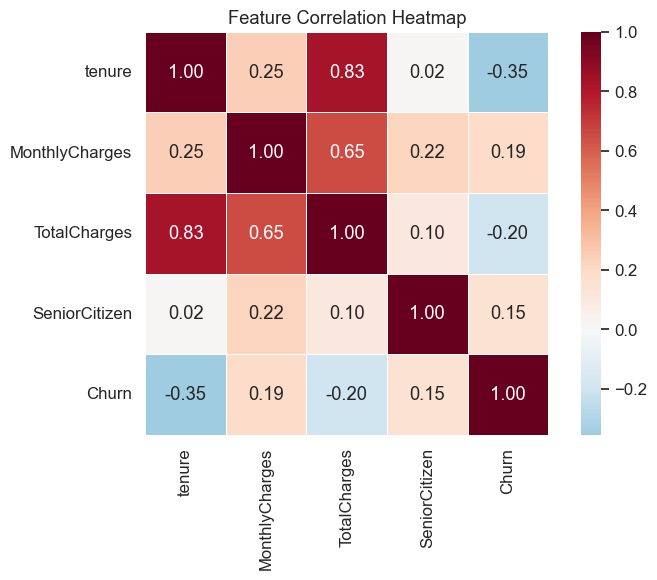

In [24]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].dropna()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations:**
- **Tenure** has a moderate negative correlation with churn (-0.35) — longer tenure = less likely to churn.
- **MonthlyCharges** has a weak positive correlation with churn (~0.19).
- **TotalCharges** correlates strongly with tenure (0.83), which makes sense — it's a product of tenure × charges.

## 7. Tenure vs Monthly Charges Scatter

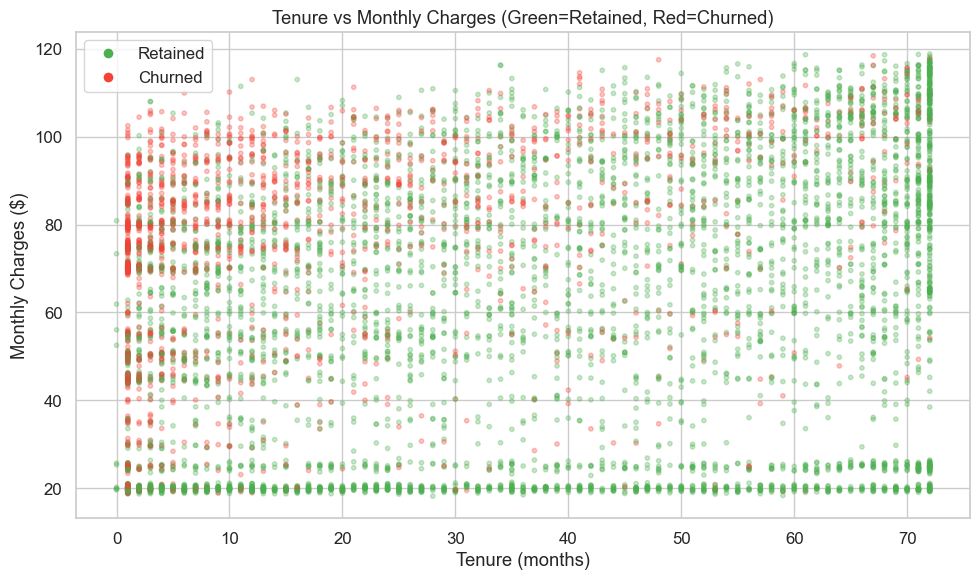

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['Churn'].map({0: '#4CAF50', 1: '#F44336'})
ax.scatter(df['tenure'], df['MonthlyCharges'], c=colors, alpha=0.3, s=10)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.set_title('Tenure vs Monthly Charges (Green=Retained, Red=Churned)')

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50', markersize=8, label='Retained'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=8, label='Churned'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

**Pattern:** The high-risk churn zone is **low tenure + high monthly charges** (top-left cluster).
Customers who stay beyond ~20 months are much less likely to churn regardless of their charges.

## 8. Service Adoption Analysis

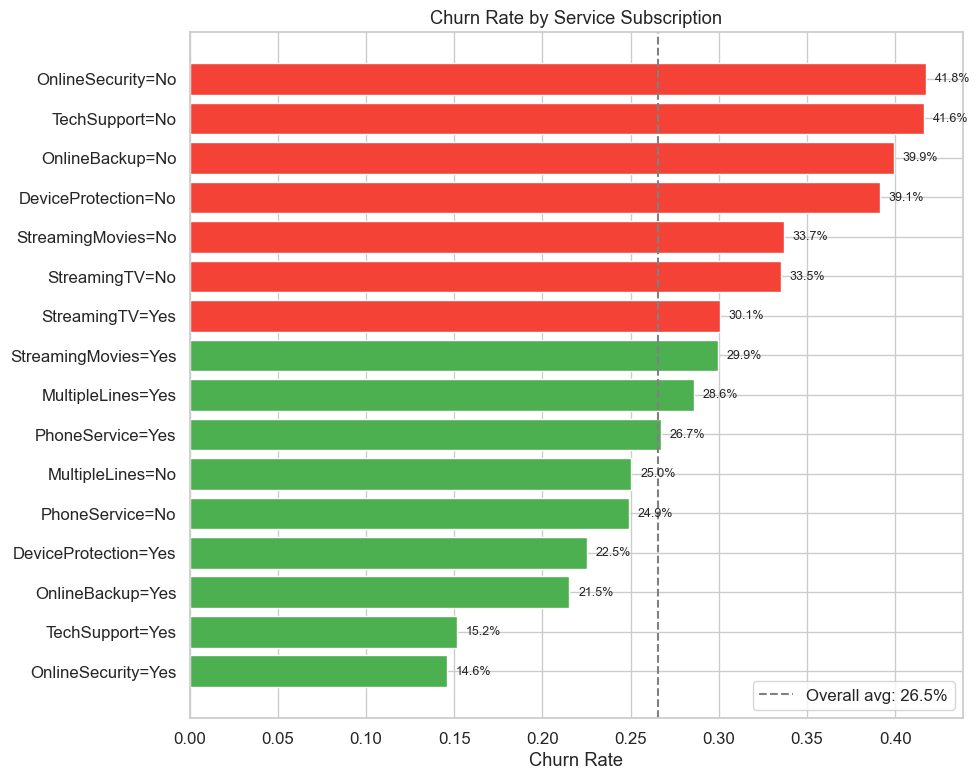

In [26]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

# Calculate churn rate for each service
service_churn = {}
for col in service_cols:
    for val in df[col].unique():
        if val in ['Yes', 'No']:
            rate = df[df[col] == val]['Churn'].mean()
            service_churn[f'{col}={val}'] = rate

service_df = pd.DataFrame.from_dict(service_churn, orient='index', columns=['Churn Rate'])
service_df = service_df.sort_values('Churn Rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if v > 0.3 else '#4CAF50' for v in service_df['Churn Rate']]
ax.barh(service_df.index, service_df['Churn Rate'], color=colors)
ax.set_xlabel('Churn Rate')
ax.set_title('Churn Rate by Service Subscription')
ax.axvline(x=df['Churn'].mean(), color='gray', linestyle='--', label=f'Overall avg: {df["Churn"].mean():.1%}')
ax.legend()

for i, v in enumerate(service_df['Churn Rate']):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Summary of Key Insights

| Finding | Detail | Impact on Modeling |
|---------|--------|--------------------|
| Class imbalance | 26.5% churn | Use `class_weight='balanced'` or SMOTE |
| Contract type is #1 predictor | Month-to-month = 42% churn | Include as categorical feature |
| Short tenure = high risk | First 12 months critical | Engineer tenure groups as feature |
| Fiber optic churn is high | ~42% churn rate | InternetService is important feature |
| Electronic check = red flag | ~45% churn rate | PaymentMethod matters |
| Service bundling reduces churn | More services = lower churn | Engineer NumServices count feature |
| High charges + low tenure | Core churn cluster | AvgMonthlySpend as derived feature |

**Features to engineer for training:**
1. `TenureGroup` — bucket tenure into 0-12m, 12-24m, 24-48m, 48-72m
2. `NumServices` — count of subscribed services
3. `AvgMonthlySpend` — TotalCharges / (tenure + 1)